<a href="https://colab.research.google.com/github/AAYUSHI003/CreditCardFraudDetection/blob/main/CredCard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec

In [11]:
data = pd.read_csv("creditcard.csv")
print(data.head())
print(data.shape)

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [12]:
from sklearn.preprocessing import StandardScaler
data['normalizedAmount'] = StandardScaler().fit_transform(data['Amount'].values.reshape(-1, 1))
data = data.drop(['Time','Amount'], axis = 1)

In [13]:
data.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Class,normalizedAmount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.140534
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073403


In [14]:
X = data.iloc[:, data.columns != 'Class']
y = data.iloc[:, data.columns == 'Class']

In [15]:
# Using Scikit-learn to split data into training and testing sets
from sklearn.model_selection import train_test_split
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size = 0.3, random_state = 0)

In [16]:
X_train.shape

(199364, 29)

In [17]:
X_test.shape

(85443, 29)

In [18]:
y_train.shape

(199364, 1)

In [20]:
X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

###Deep neural network

In [23]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout

In [24]:
model = Sequential([
    Dense(units=16, input_dim=29, activation='relu'),
    Dense(units=24, activation='relu'),
    Dropout(0.5),
    Dense(units=20, activation='relu'),
    Dense(units=24, activation='relu'),
    Dense(units=1, activation='sigmoid'),
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │           408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 20)             │           500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 24)             │           504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,917 (7.49 KB)

 Trainable params: 1,917 (7.49 KB)

 Non-trainable params: 0 (0.00 B)

###Training

In [29]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train,y_train,batch_size=15,epochs=5)

Epoch 1/5
13291/13291 ━━━━━━━━━━━━━━━━━━━━ 37s 3ms/step - accuracy: 0.9985 - loss: 0.0094
Epoch 2/5
13291/13291 ━━━━━━━━━━━━━━━━━━━━ 46s 3ms/step - accuracy: 0.9993 - loss: 0.0040
Epoch 3/5
13291/13291 ━━━━━━━━━━━━━━━━━━━━ 31s 2ms/step - accuracy: 0.9994 - loss: 0.0036
Epoch 4/5
13291/13291 ━━━━━━━━━━━━━━━━━━━━ 32s 2ms/step - accuracy: 0.9994 - loss: 0.0035
Epoch 5/5
13291/13291 ━━━━━━━━━━━━━━━━━━━━ 31s 2ms/step - accuracy: 0.9994 - loss: 0.0033


In [30]:
score = model.evaluate(X_test, y_test)
print(score)

2671/2671 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9994 - loss: 0.0045
[0.0044925217516720295, 0.9994382262229919]


In [40]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn import svm, datasets
import itertools
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
  if normalize:
    cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    print("Normalized confusion matrix")
  else:
    print('Confusion matrix, without normalization')
  print(cm)
  plt.imshow(cm, interpolation='nearest', cmap=cmap)
  plt.title(title)
  plt.colorbar()
  tick_marks = np.arange(len(classes))
  plt.xticks(tick_marks, classes, rotation=45)
  plt.yticks(tick_marks, classes)

  fmt = '.2f' if normalize else 'd'
  thresh = cm.max() / 2.
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], fmt),
             horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black")
  plt.ylabel('True label')
  plt.xlabel('Predicted label')
  plt.tight_layout()

In [85]:
y_pred_dnn = model.predict(X_test)
y_test = pd.DataFrame(y_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step 


In [86]:
cnf_matrix = confusion_matrix(y_test, y_pred_dnn.round())

In [43]:
print(cnf_matrix)

[[85275    21]
 [   27   120]]


Confusion matrix, without normalization
[[85275    21]
 [   27   120]]


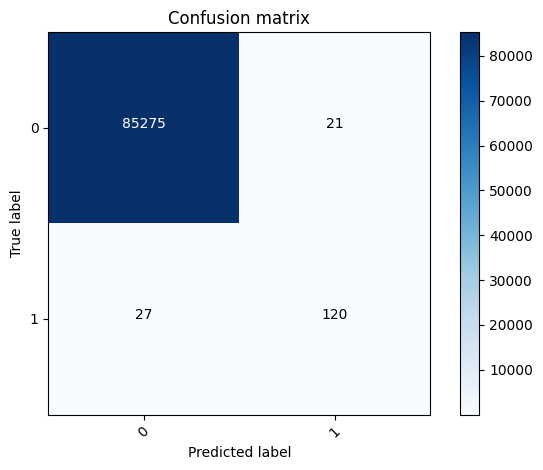

In [44]:
plot_confusion_matrix(cnf_matrix, classes=[0, 1])

8901/8901 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step
Confusion matrix, without normalization
[[283871    444]
 [    55    437]]


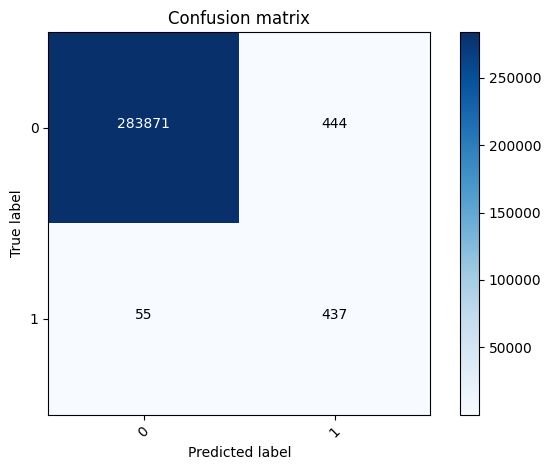

In [111]:
y_pred_dnn = model.predict(X)
y_expected = pd.DataFrame(y)
cnf_matrix = confusion_matrix(y_expected, y_pred_dnn.round())
plot_confusion_matrix(cnf_matrix, classes=[0, 1])
plt.show()

###Using Random Forest

In [46]:
from sklearn.ensemble import RandomForestClassifier

In [48]:
random_forest = RandomForestClassifier(n_estimators=100)

In [49]:
random_forest.fit(X_train, y_train.ravel())

RandomForestClassifier()

In [89]:
y_pred_rf = random_forest.predict(X_test)

In [51]:
random_forest.score(X_train, y_train)

1.0

Confusion matrix, without normalization
[[149   0]
 [ 15 132]]


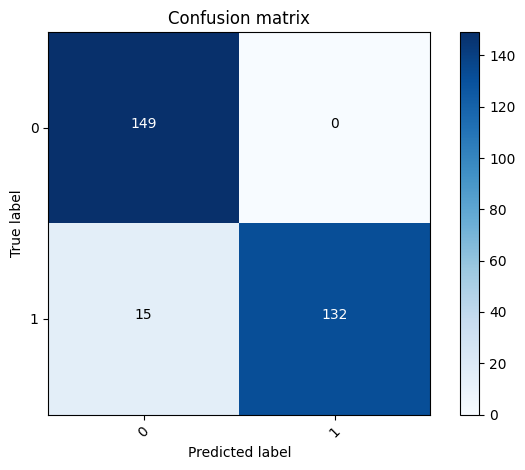

In [90]:
cnf_matrix = confusion_matrix(y_test, y_pred_rf.round())
plot_confusion_matrix(cnf_matrix, classes=[0, 1])
plt.show()

In [91]:
y_pred_rf = random_forest.predict(X)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [92]:
cnf_matrix = confusion_matrix(y, y_pred_rf.round())

Confusion matrix, without normalization
[[284308      7]
 [    34    458]]


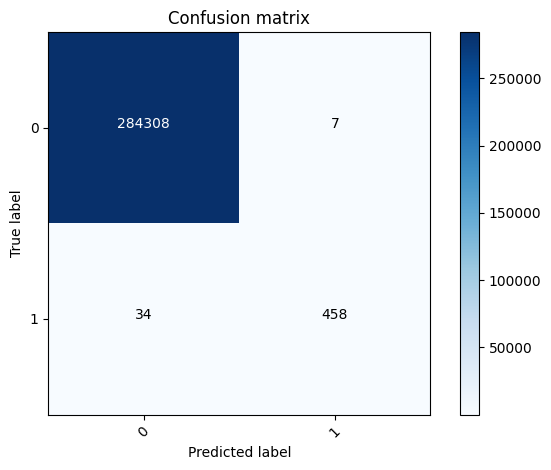

In [93]:
plot_confusion_matrix(cnf_matrix, classes=[0, 1])
plt.show()

###Using Decision trees

In [56]:
from sklearn.tree import DecisionTreeClassifier
decision_tree = DecisionTreeClassifier()

In [58]:
decision_tree.fit(X_train, y_train.ravel())

DecisionTreeClassifier()

In [94]:
y_pred_dt = decision_tree.predict(X_test)

In [60]:
decision_tree.score(X_test, y_test)

0.9992275552122467

In [95]:
y_pred_dt = decision_tree.predict(X)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


In [63]:
y_expected = pd.DataFrame(y)

Confusion matrix, without normalization
[[284286     29]
 [    37    455]]


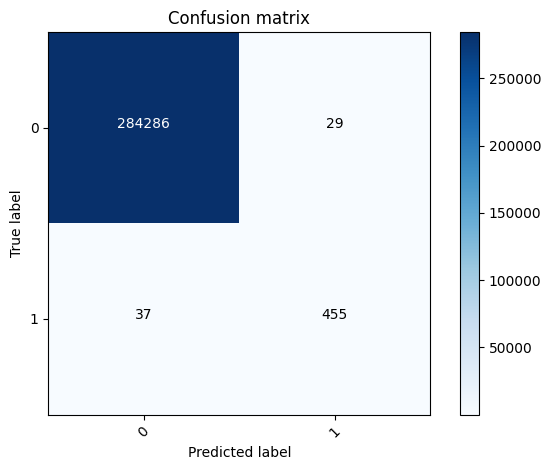

In [96]:
cnf_matrix = confusion_matrix(y_expected, y_pred_dt.round())
plot_confusion_matrix(cnf_matrix, classes=[0, 1])
plt.show()

###Undersampling

In [65]:
fraud_indices = np.array(data[data.Class == 1].index)
number_fraudrecords = len(fraud_indices)
print(number_fraudrecords)

492


In [66]:
normal_indices = np.array(data[data.Class == 0].index)

In [67]:
random_normal_indices = np.random.choice(normal_indices, number_fraudrecords, replace = False)
random_normal_indices = np.array(random_normal_indices)
print(len(random_normal_indices))

492


In [68]:
under_sample_indices = np.concatenate([fraud_indices,random_normal_indices])
print(len(under_sample_indices))

984


In [71]:
under_sample_data = data.iloc[under_sample_indices,:]

In [72]:
X_undersample = under_sample_data.iloc[:, under_sample_data.columns != 'Class']
y_undersample = under_sample_data.iloc[:, under_sample_data.columns == 'Class']

In [73]:
X_train, X_test, y_train, y_test = train_test_split(
        X_undersample, y_undersample, test_size = 0.3, random_state = 0)

In [74]:
X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

In [75]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │           408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 20)             │           500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 24)             │           504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,753 (22.48 KB)

 Trainable params: 1,917 (7.49 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,836 (14.99 KB)

In [76]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train,y_train,batch_size=15,epochs=5)

Epoch 1/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9128 - loss: 0.2506
Epoch 2/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9259 - loss: 0.1710
Epoch 3/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9331 - loss: 0.1578
Epoch 4/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9404 - loss: 0.1410
Epoch 5/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9419 - loss: 0.1343


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Confusion matrix, without normalization
[[149   0]
 [ 17 130]]


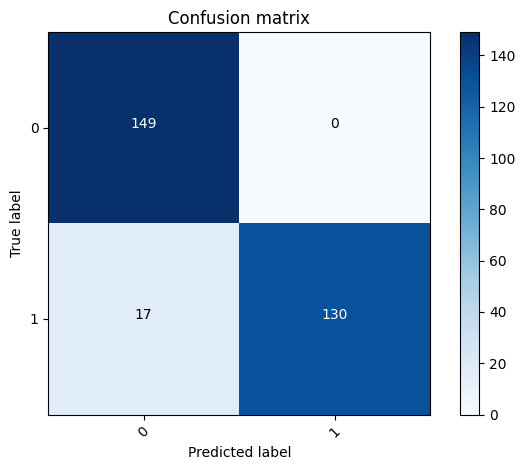

In [97]:
y_pred_us = model.predict(X_test)
y_expected = pd.DataFrame(y_test)
cnf_matrix = confusion_matrix(y_expected, y_pred_us.round())
plot_confusion_matrix(cnf_matrix, classes=[0, 1])
plt.show()

8901/8901 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step
Confusion matrix, without normalization
[[283871    444]
 [    55    437]]


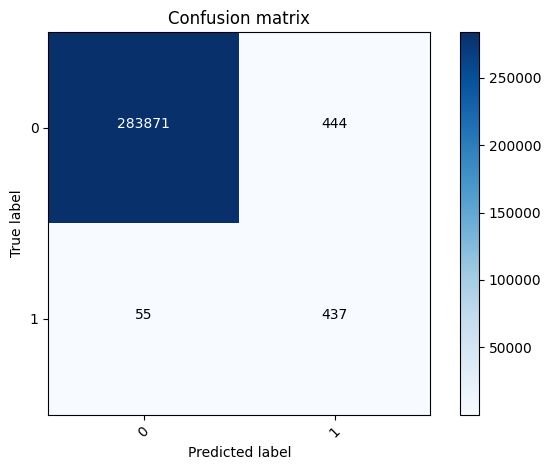

In [98]:
y_pred_us = model.predict(X)
y_expected = pd.DataFrame(y)
cnf_matrix = confusion_matrix(y_expected, y_pred_us.round())
plot_confusion_matrix(cnf_matrix, classes=[0, 1])
plt.show()

In [113]:
print("y_test shape:", y_test.shape)
print("y_pred_rf shape:", y_pred_rf.shape)
print("y_pred_dt shape:", y_pred_dt.shape)
print("y_pred_us shape:", y_pred_us.shape)

y_test shape: (296, 1)
y_pred_rf shape: (284807,)
y_pred_dt shape: (284807,)
y_pred_us shape: (284807, 1)
